# Geolocation fraud detector
Run the data preprocessing part and the basic analysis.

<class 'pandas.DataFrame'>
RangeIndex: 11799 entries, 0 to 11798
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            11799 non-null  int64  
 1   origin        11799 non-null  str    
 2   ground_truth  11799 non-null  str    
 3   guess         0 non-null      float64
 4   ip_v4         11799 non-null  str    
 5   ip_v6         2437 non-null   str    
 6   latency       11799 non-null  float64
 7   hops          11799 non-null  float64
 8   count         11799 non-null  int64  
 9   date_time     11799 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 921.9 KB


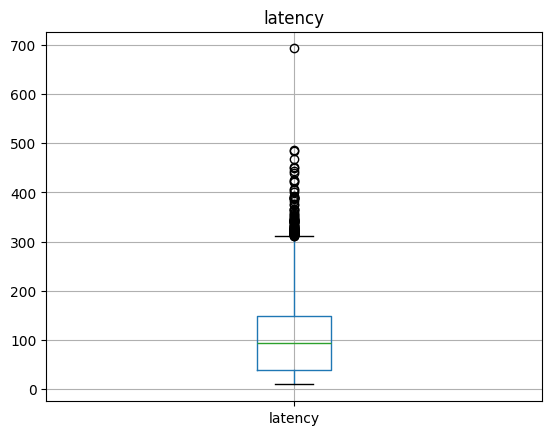

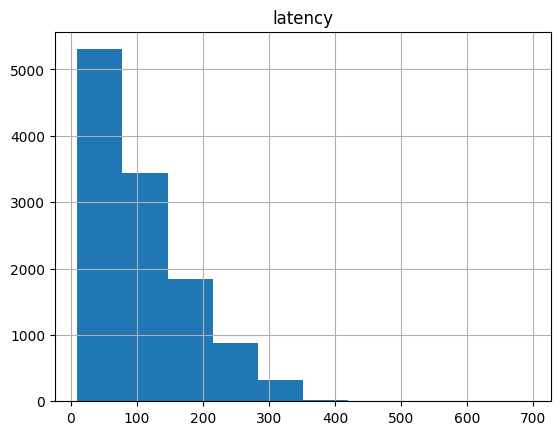

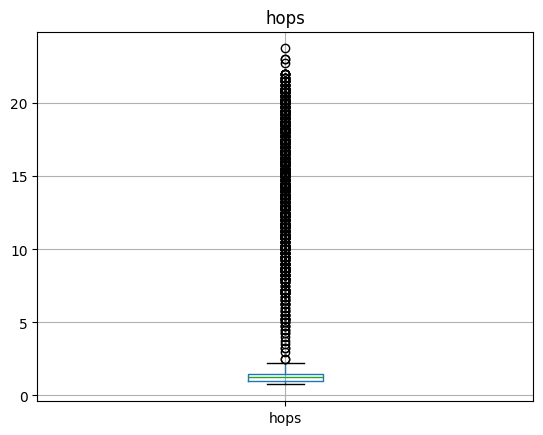

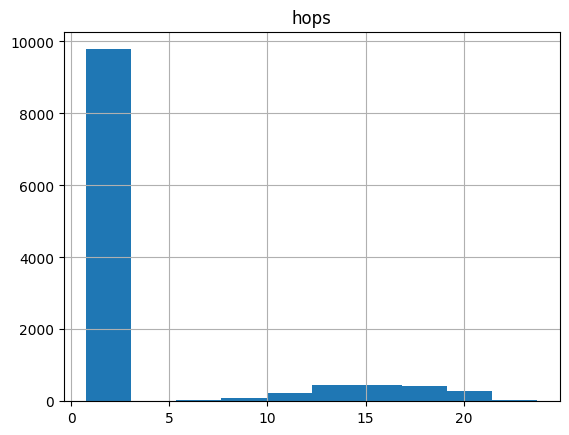

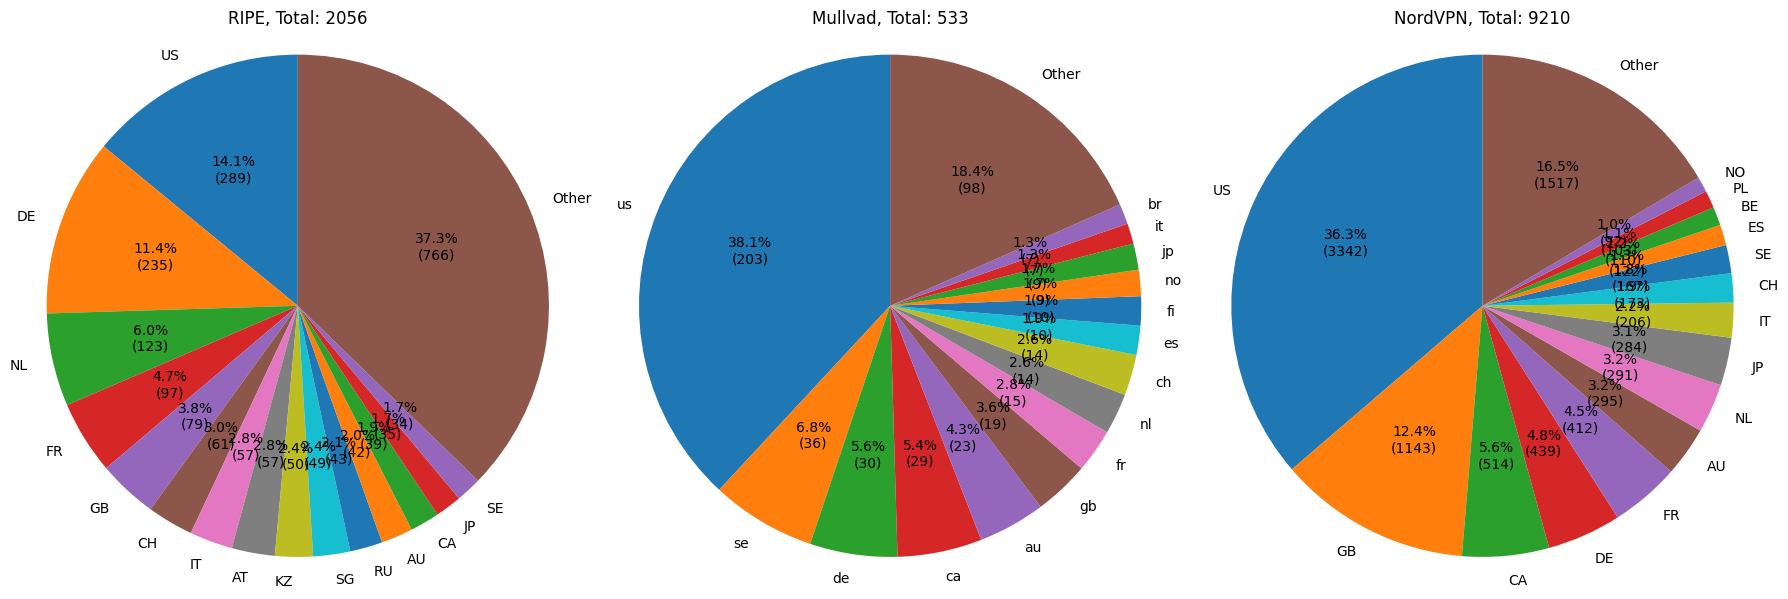

In [13]:
%run preparation.ipynb

# Metrics
As we have to predict the country of location of a given server, and because there are many countries out there, this exercise is classification exercise.  

In [14]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def generate_metrics(results: list[tuple]):
    frame = {
        "Classifiers": [], 
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1-Score": []
    }

    for result in results:
        algorithm, test_data, predictions = result

        accuracy = accuracy_score(test_data, predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(
            test_data, 
            predictions, 
            average='weighted', 
            zero_division=np.nan # type: ignore
        ) 
        frame['Classifiers'].append(algorithm)
        frame['Accuracy'].append(accuracy)
        frame['Precision'].append(precision)
        frame['Recall'].append(recall)
        frame['F1-Score'].append(f1)

    return pd.DataFrame(data=frame)

# Models' selection

Fundamentally, our task is about guessing the country of location of a given server, based on a two basic network measurements. This makes this whole exercise a categorisation exercise. 

First and foremost, we will implement models based on exisiting papers. Two models have been selected from the existing litterature based on the fact they only require a single host executing the measurements, and on their use of any machine-learning or statistical technique to guess the location:
 - A Naive-bayes guesser Erikson et al, who has shown to be more reliable than Constraint-based geolocation for targets less than 1000 miles away and using both round-time trip and topology as features. The population-density feature will be left out, however. 
 - A neural-network guesser by Jiang et al, using round-time trip as only determining feature, limited to a single measurement host, and to a single tier. 

Whilst Constraint-Based Geolocation(CBG) is suspected to remain the gold-standard, it would require a dense array of hosts capable of executing those measurements, defeating the point of a single-host geolocation predicator. Naturally, all other methods, like Erikson's latter Posit, which are based on CGB algorithms, are ruled-out. 
Surprisingly, Erikson's last paper on geolocation asserted that the statistical approach was one of the best methods available and outperformed single CBG implementations.

## Naive bayes

### Transformation
Now let's finish the transformation on the train set. Because our features 'latency' and 'hops' follow a non-gaussian distribution and display numerous outliers, a simple Min-Max normalisation should suffice to make sure both features are on the same scale. A Z-score normalisation would have been inappropriate directly due to the non-gaussian nature of our distribution. 

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
import pandas as pd
import numpy as np
from sklearn import set_config

set_config(transform_output="pandas")

def sqrt_transform(df):
    # df is a DataFrame with one column (latency)
    result = np.sqrt(df.values)
    return pd.DataFrame(result, index=df.index, columns=["sqrt"])

nb_preprocessing = ColumnTransformer([
    # Scale original latency and hops
    ("smot_and_standardise", MinMaxScaler(), ["latency", "hops"]),
    # Add sqrt(latency) as a new column (not scaled here)
    ("sqrt", FunctionTransformer(sqrt_transform), ["latency"]),
    ("untouched", FunctionTransformer(lambda x: x), ["hops"])
], remainder='passthrough')

prepared_train_set = nb_preprocessing.fit_transform(train_set) # type: ignore
prepared_dev_set = nb_preprocessing.fit_transform(dev_set) # type: ignore
prepared_dev_set

,smot_and_standardise__latency,smot_and_standardise__hops,sqrt__sqrt,untouched__hops,remainder__origin,remainder__ground_truth
205,0.444910,0.483146,13.145294,12.25,RIPE,BR
1722,0.296286,0.629213,10.900264,15.50,RIPE,US
449,0.077765,0.842697,6.280506,20.25,RIPE,DE
1924,0.767420,0.820225,17.027639,19.75,RIPE,US
1326,0.055131,0.617978,5.587822,15.25,RIPE,NL
...,...,...,...,...,...,...
1030,0.140644,0.786517,7.891990,19.00,RIPE,IT
1302,0.049792,0.921348,5.411492,22.00,RIPE,NL
1462,0.160899,0.382022,8.345088,10.00,RIPE,RU
527,0.061520,0.752809,5.791740,18.25,RIPE,DE



### Execution
Unfortunately, it seems the good performance of the Naive-bayes classifier cannot seem to be replicated.
It is suspected the missing population density matrix or the lack of many measurement hosts were critical components of the datasets, thus tanking the overall performance of the classifier. Other normalisation transformers were tested (PowerTransformer and QuartileTransformer), but worsened the classifier's performance even more.

In [16]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

feature_columns = ['sqrt__sqrt', 'untouched__hops']
label_column = 'remainder__ground_truth'
x_train = prepared_train_set[feature_columns]   # type: ignore # shape (n_samples, 2)
y_train = prepared_train_set[label_column] # type: ignore

x_test = prepared_dev_set[feature_columns] # type: ignore
y_test = prepared_dev_set[label_column] # type: ignore

results: list[tuple] = []
gaussian_nb_predictions = gnb.fit(x_train, y_train).predict(x_test)
results.append(("Naive-Bayes", y_test, gaussian_nb_predictions))

generate_metrics(results)

,Classifiers,Accuracy,Precision,Recall,F1-Score
0,Naive-Bayes,0.376947,0.352557,0.376947,0.271556


## Multinomial SVM classifier

Following Geron's first multiclass attempt at a classifier, a one-versus-all classifier was assessed. Normally, SVM applies only to binary classification, but a SVm with one-versus-all strategie handles multiclass classification by training a separate binary SVM classifier for each class against all others combined, predicting the class with the highest confidence score. This also has for major advantage to grant us a way to measure how reliable each guess was. 

### Preparation

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

numerical_preprocessor = make_pipeline(
    PolynomialFeatures(degree=3),
    MinMaxScaler(),
)

svm_preprocesor = ColumnTransformer([
    ("prepare", numerical_preprocessor, ["latency", "hops"]),
], remainder='passthrough')

prepared_train_set = svm_preprocesor.fit_transform(train_set) # type: ignore
prepared_dev_set = svm_preprocesor.fit_transform(dev_set) # type: ignore
prepared_dev_set

,prepare__1,prepare__latency,prepare__hops,prepare__latency^2,prepare__latency hops,prepare__hops^2,prepare__latency^3,prepare__latency^2 hops,prepare__latency hops^2,prepare__hops^3,remainder__origin,remainder__ground_truth
205,0.0,0.444910,0.483146,0.212289,0.340726,0.263099,0.098275,0.159754,0.228480,0.137003,RIPE,BR
1722,0.0,0.296286,0.629213,0.099896,0.295007,0.423629,0.031930,0.095181,0.251625,0.277792,RIPE,US
449,0.0,0.077765,0.842697,0.010213,0.121712,0.725887,0.001142,0.012878,0.142128,0.619751,RIPE,DE
1924,0.0,0.767420,0.820225,0.599300,0.940517,0.690288,0.464347,0.728554,1.000000,0.574949,RIPE,US
1326,0.0,0.055131,0.617978,0.006065,0.068107,0.409945,0.000553,0.005567,0.063233,0.264554,RIPE,NL
...,...,...,...,...,...,...,...,...,...,...,...,...
1030,0.0,0.140644,0.786517,0.026801,0.185625,0.638558,0.004576,0.031420,0.197976,0.511877,RIPE,IT
1302,0.0,0.049792,0.921348,0.005227,0.096038,0.857492,0.000452,0.007324,0.124414,0.794784,RIPE,NL
1462,0.0,0.160899,0.382022,0.033730,0.104704,0.173990,0.006408,0.020344,0.060600,0.074413,RIPE,RU
527,0.0,0.061520,0.752809,0.007138,0.090709,0.588831,0.000692,0.008057,0.097849,0.453593,RIPE,DE


### Execution

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

svc = SVC(C=1000, kernel='rbf', max_iter=100000, random_state=4269)

feature_columns = ['prepare__latency', 'prepare__hops']
label_column = 'remainder__ground_truth'
x_train = prepared_train_set[feature_columns]   # type: ignore # shape (n_samples, 2)
y_train = prepared_train_set[label_column] # type: ignore

x_test = prepared_dev_set[feature_columns] # type: ignore
y_test = prepared_dev_set[label_column] # type: ignore

parameters = {'kernel':('linear', 'rbf', 'poly'), 'C':[0.1, 1, 10, 100, 1000], 'max_iter':[1000, 10_000, 100_000]}

mlp = GridSearchCV(svc, parameters, cv=5, scoring="accuracy")
mlp.fit(x_train, y_train)
# Access the best hyperparameters found by GridSearchCV
best_params = mlp.best_params_
best_model = mlp.best_estimator_
best_params


d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\svm\_base.py:313: Conve

{'C': 1000, 'kernel': 'rbf', 'max_iter': 100000}

In [19]:
svm_predictions = svc.fit(x_train, y_train).predict(x_test)
#best_model
results.append(("SVM", y_test, svm_predictions))
generate_metrics(results)

,Classifiers,Accuracy,Precision,Recall,F1-Score
0,Naive-Bayes,0.376947,0.352557,0.376947,0.271556
1,SVM,0.314642,0.318647,0.314642,0.258457


## Decision-tree classifier 

### Preparation 

In [20]:
def sqrt_transform(df):
    # df is a DataFrame with one column (latency)
    result = np.sqrt(df.values)
    return pd.DataFrame(result, index=df.index, columns=["sqrt"])

nb_preprocessing = ColumnTransformer([
    # Scale original latency and hops
    ("standardise", MinMaxScaler(), ["latency", "hops"]),
], remainder='passthrough')

prepared_train_set = nb_preprocessing.fit_transform(train_set) # type: ignore
prepared_dev_set = nb_preprocessing.fit_transform(dev_set) # type: ignore
prepared_train_set

,standardise__latency,standardise__hops,remainder__ground_truth
0,0.036451,0.625000,NL
1,0.125571,0.659091,SE
2,0.052030,0.659091,DE
3,0.074523,0.875000,AT
4,0.064354,0.568182,DE
...,...,...,...
1490,0.105149,0.829545,BG
1491,0.098548,0.897727,BG
1492,0.115234,0.738636,BG
1493,0.093925,0.636364,BG


# Execution

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

dtc = DecisionTreeClassifier(max_depth=2, random_state=4269)
nkc = KNeighborsClassifier(n_neighbors=10)

feature_columns = ['standardise__latency', 'standardise__hops']
label_column = 'remainder__ground_truth'
x_train = prepared_train_set[feature_columns]   # type: ignore # shape (n_samples, 2)
y_train = prepared_train_set[label_column] # type: ignore

x_test = prepared_dev_set[feature_columns] # type: ignore
y_test = prepared_dev_set[label_column] # type: ignore

dtc_predictions = dtc.fit(x_train, y_train).predict(x_test)
#best_model
results.append(("Decision Tree", y_test, dtc_predictions))
nkc_predictions = nkc.fit(x_train, y_train).predict(x_test)
results.append(("Nearest Neighbour", y_test, nkc_predictions))
generate_metrics(results)

,Classifiers,Accuracy,Precision,Recall,F1-Score
0,Naive-Bayes,0.376947,0.352557,0.376947,0.271556
1,SVM,0.314642,0.318647,0.314642,0.258457
2,Decision Tree,0.320872,0.364601,0.320872,0.177208
3,Nearest Neighbour,0.286604,0.297719,0.286604,0.270813


# Ensemble learning 

In [ ]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(solver="adam", hidden_layer_sizes=(5), random_state=42, max_iter=3000).fit(x_train, y_train)
mlp_predictions = mlp.predict(x_test)
results.append(("MLP", y_test, mlp_predictions))
generate_metrics(results)

d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.